# Test of Single Frequency NW Extraction

In [3475]:
import numpy as np
import matplotlib.pyplot as plt
import receiver_simulation
import noise_wave_gcr
import corner

In [3476]:
n_samp = int(1e6)

T_l = 273+20 # K
T_ns = 273+50 # K
T_src = 273+20 # K

t_int = 60*60 # seconds
delta_nu = 20e6 / 30 # Hz

gain = 1

# Gammas
gamma_rec = 0.1+0.1j

gamma_src_list = [0.5-0.5j,1,-1, 0.1j+0.1, -0.1j-0.1]

gamma_l = 0
gamma_ns = 0

# Receiver Noise Terms
T_unc = 300
T_0 = 350
T_sin = 30
T_cos = -30

# Temperature Sensor
temp_sens_variance = 0.1**2


### Simulate Receiver Measurements

In [ ]:
def return_measurements_i(T_l, T_ns, T_src,
                        gamma_rec, gamma_src_list,
                        gamma_ns, gamma_l,
                        t_int, delta_nu,
                        T_unc, T_cos, T_sin,
                        T_0,
                        gain,
                        temp_sens_variance,
                        add_noise=True):
    n_meas = len(gamma_src_list)

    p_src = np.ones(shape=(n_meas,))
    p_ns = np.ones(shape=(n_meas,))
    p_l = np.ones(shape=(n_meas,))

    T_src_meas = np.ones(shape=(n_meas,))
    T_ns_meas = np.ones(shape=(n_meas,))
    T_l_meas = np.ones(shape=(n_meas,))

    for i in range(n_meas):
        p_src[i] = receiver_simulation.compute_radiometer_power(T_src,
                                                                T_unc,
                                                                T_sin,
                                                                T_cos,
                                                                T_0,
                                                                gamma_rec,
                                                                gamma_src_list[i],
                                                                gain,
                                                                add_noise=add_noise,
                                                                t_int=t_int,
                                                                delta_nu=delta_nu)
        p_ns[i] = receiver_simulation.compute_radiometer_power(T_ns,
                                                                T_unc,
                                                                T_sin,
                                                                T_cos,
                                                                T_0,
                                                                gamma_rec,
                                                                gamma_ns,
                                                                gain,
                                                                add_noise=add_noise,
                                                                t_int=t_int,
                                                                delta_nu=delta_nu)
        p_l[i] = receiver_simulation.compute_radiometer_power(T_l,
                                                                T_unc,
                                                                T_sin,
                                                                T_cos,
                                                                T_0,
                                                                gamma_rec,
                                                                gamma_l,
                                                                gain,
                                                                add_noise=add_noise,
                                                                t_int=t_int,
                                                                delta_nu=delta_nu)
        
        if add_noise:
            T_src_meas[i] = np.abs(np.random.normal(T_src, scale=np.sqrt(temp_sens_variance)))
            T_ns_meas[i] = np.abs(np.random.normal(T_ns, scale=np.sqrt(temp_sens_variance)))
            T_l_meas[i] = np.abs(np.random.normal(T_l, scale=np.sqrt(temp_sens_variance)))
        else:
            T_src_meas[i] = T_src
            T_l_meas[i] = T_l
            T_ns_meas[i]=T_ns
        pass
    return {"T_src":T_src_meas,
                "T_L":T_l_meas,
                "T_NS":T_ns_meas,
                "P_src":p_src,
                "P_L":p_l,
                "P_NS":p_ns}


In [ ]:
measurement_set = return_measurements_i(T_l=T_l,
                                      T_ns=T_ns,
                                      T_src=T_src,
                                      gamma_rec=gamma_rec,
                                      gamma_l=0,
                                      gamma_ns=0,
                                      gamma_src_list=gamma_src_list,
                                      t_int=t_int,
                                      delta_nu=delta_nu,
                                      T_0=T_0,
                                      T_cos=T_cos,
                                      T_sin=T_sin,
                                      T_unc=T_unc,
                                      temp_sens_variance=temp_sens_variance,
                                      gain=gain,
                                      add_noise=True)


In [3479]:
d, N_inv = noise_wave_gcr.construct_d_vector_and_cov_matrix(p_src=measurement_set['P_src'],
                                                        p_l=measurement_set['P_L'],
                                                        p_ns=measurement_set['P_NS'],
                                                        T_src=measurement_set['T_src'],
                                                        T_ns=measurement_set["T_NS"],
                                                        T_l=measurement_set['T_L'],
                                                        Gamma_rec=gamma_rec,
                                                        Gamma_src=np.array(gamma_src_list),
                                                        temp_sens_variance=temp_sens_variance,
                                                        t_int=t_int,
                                                        delta_nu=delta_nu, inverse_noise_covariance=True)


H = noise_wave_gcr.construct_basic_H_matrix(gamma_rec=gamma_rec, gamma_src_list=gamma_src_list)

In [3480]:
theta = np.linalg.lstsq(H, d)

print(theta[0])

[300.09636252 -30.01820686  29.78003615]


In [3481]:
print(len(gamma_src_list))
print(d.shape)

5
(5,)


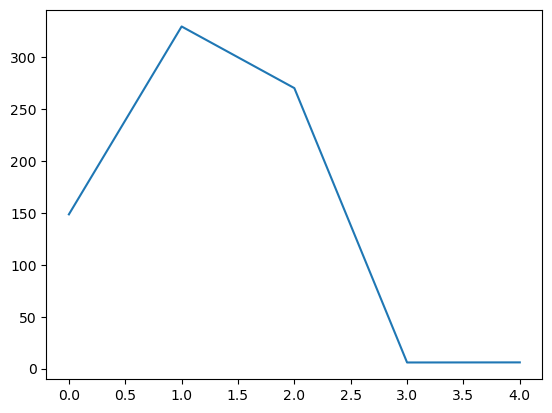

In [3482]:
plt.plot(d)

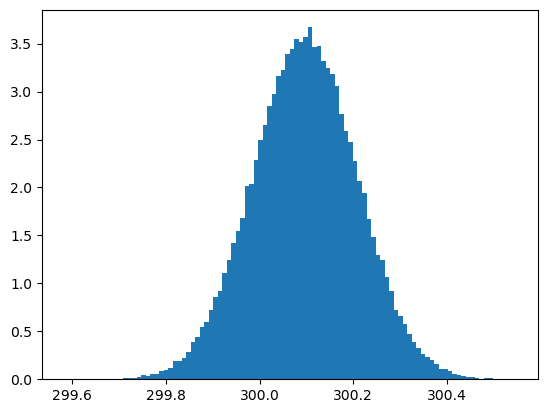

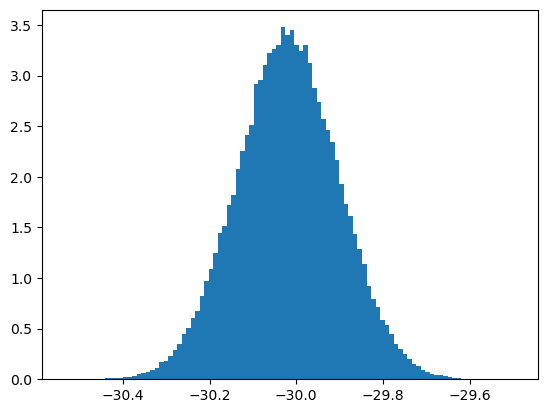

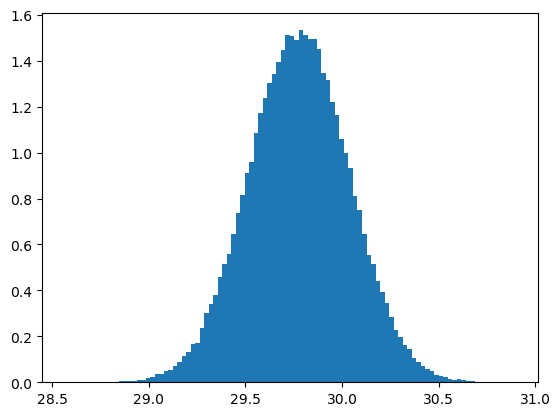

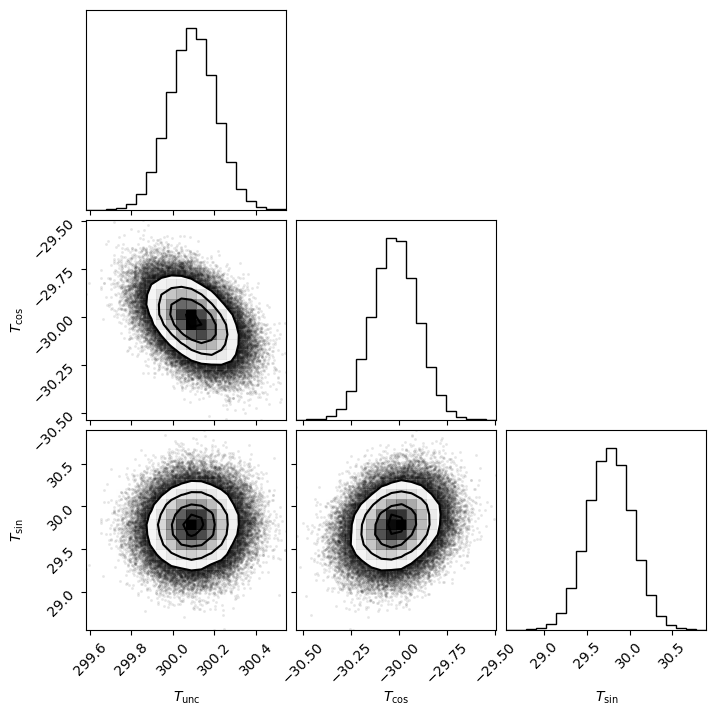

In [3483]:
n_samp = int(10e4)

results = []
for _ in range(n_samp):
    lhs = H.T@N_inv@H

    rhs = (H.T @ N_inv @ d) + (H.T @ np.sqrt(N_inv) @ np.random.normal(loc=0, scale=1, size=d.shape))


    Theta = np.linalg.lstsq(lhs, rhs)
    results.append(Theta[0])
results = np.array(results)

T_unc_dist = results[:,0]
T_cos_dist = results[:,1]
T_sin_dist = results[:,2]

plt.hist(T_unc_dist,bins=100, density=True)
plt.show()
plt.hist(T_cos_dist, bins=100,density=True)
plt.show()
plt.hist(T_sin_dist,bins=100, density=True)
plt.show()



figure = corner.corner(data=results,
                       labels=[r'$T_{\rm unc}$',
                               r'$T_{\rm cos}$',
                               r'$T_{\rm sin}$'])
plt.show()